In [ ]:
# Download the dataset file to local storage (from publicly shared drive file)
# Original source: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques
# (The rest of the notebook expects the original housing.csv to be present in the current directory)
!gdown 1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP

Downloading...
From: https://drive.google.com/uc?id=1Yhw8tBCmjYrDZ5Rm1xPrP2y5bmBmxoEP
To: /content/housing.csv
100% 461k/461k [00:00<00:00, 100MB/s]


In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

In [ ]:
import pandas as pd
df = pd.read_csv(r"/content/housing.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
display(df)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
# sump up all the NaN values in a particular column and sort them in descending order
df.isna().sum().sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
...,...
MoSold,0
YrSold,0
SaleType,0
SaleCondition,0


In [ ]:
#@title Display all the number of nan values in each column and type
column_stats_raw = []

for column_name in df.columns:
  column_stats_raw.append((column_name, df[column_name].dtype, df[column_name].isna().sum()))
column_stats_raw

column_stats_df = pd.DataFrame(column_stats_raw, columns=['Column name', 'Type', 'Number of null values'])
print(column_stats_df)

column_stats_df.sort_values(by ='Number of null values', ascending = False, inplace = True)

#print(column_stats_df.to_string())
display(column_stats_df)

      Column name     Type  Number of null values
0              Id    int64                      0
1      MSSubClass    int64                      0
2        MSZoning   object                      0
3     LotFrontage  float64                    259
4         LotArea    int64                      0
..            ...      ...                    ...
76         MoSold    int64                      0
77         YrSold    int64                      0
78       SaleType   object                      0
79  SaleCondition   object                      0
80      SalePrice    int64                      0

[81 rows x 3 columns]


,Column name,Type,Number of null values
72,PoolQC,object,1453
74,MiscFeature,object,1406
6,Alley,object,1369
73,Fence,object,1179
25,MasVnrType,object,872
...,...,...,...
76,MoSold,int64,0
77,YrSold,int64,0
78,SaleType,object,0
79,SaleCondition,object,0


In [ ]:
df["LotFrontage"].isna().sum()

np.int64(259)

In [ ]:
df["SalePrice"].isna()
1460-259

1201

In [ ]:
# Deletion of rows with missing data

# Scenario: We are trying to test the correlation between LotFrontage and SalePrice,
# therefore we remove the rows that have NA values for them
df.dropna(subset=["LotFrontage", "SalePrice"])

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [ ]:
column_stats_raw = []
for column_name in df.columns:
  column_stats_raw.append((column_name, df[column_name].dtype, df[column_name].isna().sum()))

column_stats_df = pd.DataFrame(column_stats_raw, columns=['Column name', 'Type', 'Number of null values'])
column_stats_df.sort_values(by ='Number of null values', ascending = False, inplace = True)

print(column_stats_df.to_string())

      Column name     Type  Number of null values
72         PoolQC   object                   1453
74    MiscFeature   object                   1406
6           Alley   object                   1369
73          Fence   object                   1179
25     MasVnrType   object                    872
57    FireplaceQu   object                    690
3     LotFrontage  float64                    259
63     GarageQual   object                     81
60   GarageFinish   object                     81
58     GarageType   object                     81
59    GarageYrBlt  float64                     81
64     GarageCond   object                     81
35   BsmtFinType2   object                     38
32   BsmtExposure   object                     38
31       BsmtCond   object                     37
30       BsmtQual   object                     37
33   BsmtFinType1   object                     37
26     MasVnrArea  float64                      8
42     Electrical   object                      1


In [ ]:
display(df["LotFrontage"])

,LotFrontage
0,65.0
1,80.0
2,68.0
3,60.0
4,84.0
...,...
1455,62.0
1456,85.0
1457,66.0
1458,68.0


In [ ]:
# Mean/Median Imputation

# We are considering LotFrontage again as it is in float (numerical) and has null values

meanLotFrontage = df["LotFrontage"].mean()
medianLotFrontage = df["LotFrontage"].median()

meanImputedLotFrontage = df["LotFrontage"].fillna(meanLotFrontage)
medianImputedLotFrontage = df["LotFrontage"].fillna(medianLotFrontage)

# Showing all values might not be the best option here given the size,
# therefore using mean/median to show that math is maintained

print("Mean before performing mean imputation:", meanLotFrontage)
print("Mean after performing mean imputation:", meanImputedLotFrontage.mean())
print()
print("Median before performing median imputation:", medianLotFrontage)
print("Median after performing median imputation:", medianImputedLotFrontage.median())
print()
print("Both are almost the same/maintained because of the kind of imputation performed here.")

Mean before performing mean imputation: 70.04995836802665
Mean after performing mean imputation: 70.04995836802664

Median before performing median imputation: 69.0
Median after performing median imputation: 69.0

Both are almost the same/maintained because of the kind of imputation performed here.


In [ ]:
# Mode imputation
# (Can be considered in cases of non-numeric values where mean/median averaging isn't possible)

print("Unique values of BsmtQual/Basement Quality column:", set(df["BsmtQual"]))

uniqueBsmtQuals = set(df["BsmtQual"])
print(df["BsmtQual"].mode())


# Multiple modes can exist if max count is same, therefore considering only the first one for imputation
modeBsmtQual = df["BsmtQual"].mode()[0]

print("Most repeated value of BsmtQual column:", modeBsmtQual)

print()
print("Current number of NaN values in BsmtQual:", df["BsmtQual"].isna().sum())

modeImputedBsmtQual = df["BsmtQual"].fillna(modeBsmtQual)

print("After imputation, the number of NaN values now are,", modeImputedBsmtQual.isna().sum())

Unique values of BsmtQual/Basement Quality column: {'Ex', 'TA', nan, 'Fa', 'Gd'}
0    TA
Name: BsmtQual, dtype: object
Most repeated value of BsmtQual column: TA

Current number of NaN values in BsmtQual: 37
After imputation, the number of NaN values now are, 0


In [ ]:
# Arbitrary value imputation (remaining)
# (Value chosen by analyst with his domain knowledge or their understanding of the dataset)

# For example, we could choose

arbitary_value = 21.0

print("Mean of LotFrontage before arbitrary value imputation:", df["LotFrontage"].mean())
arbitaryValueImputedCol = df["LotFrontage"].fillna(arbitary_value)
print("Mean of LotFrontage after arbitrary value imputation: ", arbitaryValueImputedCol.mean())

Mean of LotFrontage before arbitrary value imputation: 70.04995836802665
Mean of LotFrontage after arbitrary value imputation:  61.3486301369863


In [ ]:
# End of tail Imputation
minLotFrontage = df["LotFrontage"].min()
maxLotFrontage = df["LotFrontage"].max()

chosenTail = minLotFrontage
print("Chosen tail value:", chosenTail)

print("Mean before end of tail imputation:", df["LotFrontage"].mean())
tailImputedLotFrontage = df["LotFrontage"].fillna(chosenTail)
print("Mean after end of tail imputation:", tailImputedLotFrontage.mean())

Chosen tail value: 21.0
Mean before end of tail imputation: 70.04995836802665
Mean after end of tail imputation: 61.3486301369863


In [ ]:
chosenTail = maxLotFrontage
print("Chosen tail value:", chosenTail)

print("Mean before end of tail imputation:", df["LotFrontage"].mean())
tailImputedLotFrontage = df["LotFrontage"].fillna(chosenTail)
print("Mean after end of tail imputation:", tailImputedLotFrontage.mean())

Chosen tail value: 313.0
Mean before end of tail imputation: 70.04995836802665
Mean after end of tail imputation: 113.1486301369863


In [ ]:
display(pd.isnull(df['LotFrontage']))
display(df['LotFrontage'].isna().sum())

,LotFrontage
0,False
1,False
2,False
3,False
4,False
...,...
1455,False
1456,False
1457,False
1458,False


np.int64(259)

In [ ]:
# Random sample imputation (runtime error with logic)
import random

print("NaN values in FireplaceQu before sampling imputation:", df["FireplaceQu"].isna().sum())

# Random sample Imputation (on Fireplace Quality column)
random_sample_size = 10
random_sample = df["FireplaceQu"].dropna().sample(n=random_sample_size)\

display(random_sample)
display(len(random_sample))
display(random_sample.sample())

impute_random_sample = lambda x: random_sample.sample().iloc[0] if pd.isnull(x) else x

# Apply the lambda function to impute missing values in the "FireplaceQu" column
random_sample_imputed_col = df["FireplaceQu"].apply(impute_random_sample)

print("NaN values in FireplaceQu after sampling imputation: ", random_sample_imputed_col.isna().sum())

NaN values in FireplaceQu before sampling imputation: 690


,FireplaceQu
189,Gd
1168,TA
1031,TA
401,Gd
667,Fa
24,TA
1329,TA
599,TA
1400,Gd
20,Gd


10

,FireplaceQu
1400,Gd


NaN values in FireplaceQu after sampling imputation:  0


In [ ]:
#   Frequent category Imputation (same as mode imputation)
print("Unique values of GarageType column:", set(df["GarageType"]))

# Multiple modes can exist if max count is same, therefore considering only the first one for imputation
modeGarageType = df["GarageType"].mode()[0]

print("Most repeated value of GarageType column:", modeGarageType)

print()
print("Current number of NaN values in BsmtQual:", df["GarageType"].isna().sum())
freqCatImputatedCol = df["GarageType"].fillna(modeGarageType)
print("After imputation, the number of NaN values now are:", freqCatImputatedCol.isna().sum())

Unique values of GarageType column: {'CarPort', nan, 'Basment', 'Attchd', 'BuiltIn', 'Detchd', '2Types'}
Most repeated value of GarageType column: Attchd

Current number of NaN values in BsmtQual: 81
After imputation, the number of NaN values now are: 0


In [ ]:
# Adding a new category as "missing"
# (Replacing NaN values with explicit category such as "missing" as a common category for them)

missing_category = "Unknown"

print("Set of unique values in GarageType col before given imputation:", set(df["GarageType"]))
imputedColumn = df["GarageType"].fillna(missing_category)
print("Set of unique values in GarageType col after given imputation:", set(imputedColumn))

Set of unique values in GarageType col before given imputation: {'CarPort', nan, 'Basment', 'Attchd', 'BuiltIn', 'Detchd', '2Types'}
Set of unique values in GarageType col after given imputation: {'CarPort', 'Basment', 'Attchd', 'BuiltIn', 'Unknown', 'Detchd', '2Types'}


In [ ]:
# Regression
# We'll be using SalePrice (x) to predict LotFrontage (y) for missing/nan values
# becuase the SalePrice is not null in any row
from sklearn.linear_model import LinearRegression

model = LinearRegression()
imputed_df = df.dropna(subset=["LotFrontage"])[["LotFrontage", "SalePrice"]]
display(imputed_df)
X = imputed_df.SalePrice.values.reshape(len(imputed_df), 1)
Y = imputed_df.LotFrontage.values.reshape(len(imputed_df), 1)
model.fit(X, Y)

regression_imputed_lot_frontage = df[["LotFrontage", "SalePrice"]].apply(lambda x: model.predict([[x["SalePrice"]]])[0][0] if pd.isnull(x["LotFrontage"]) else x["LotFrontage"], axis=1)

print("Mean before regression imputation of LotFrontage:", df["LotFrontage"].mean())
print("Number NA values before imputation:", df["LotFrontage"].isna().sum())
print()
print("Number NA values after imputation:", regression_imputed_lot_frontage.isna().sum())
print("Mean after regression", regression_imputed_lot_frontage.mean())

,LotFrontage,SalePrice
0,65.0,208500
1,80.0,181500
2,68.0,223500
3,60.0,140000
4,84.0,250000
...,...,...
1455,62.0,175000
1456,85.0,210000
1457,66.0,266500
1458,68.0,142125


Mean before regression imputation of LotFrontage: 70.04995836802665
Number NA values before imputation: 259

Number NA values after imputation: 0
Mean after regression 70.065399342723


### Simple Linear Regression Example

This example demonstrates the basics of Linear Regression using synthetic data. We will create a simple dataset, fit a linear model, and visualize the regression line.

Intercept: 51.53
Slope (Coefficient): 0.000102


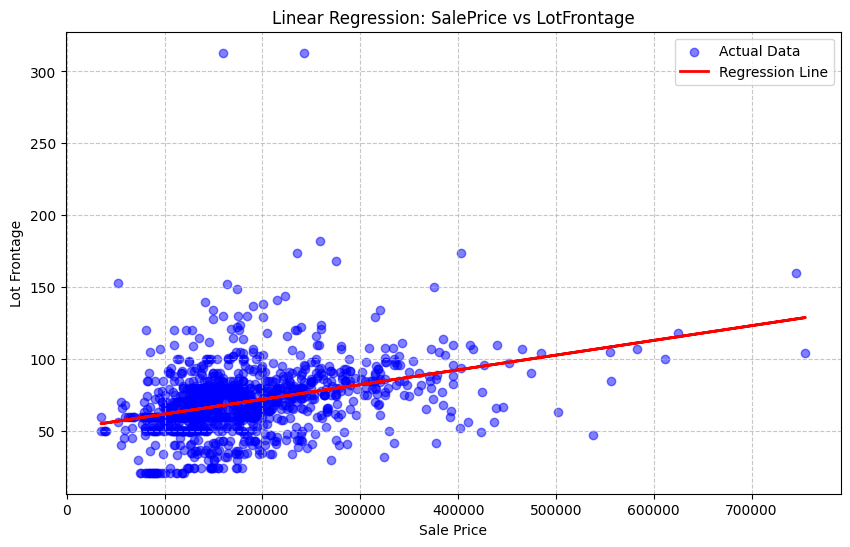

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Using the already existing imputed_df (which has LotFrontage and SalePrice)
# X = Independent variable (SalePrice), Y = Dependent variable (LotFrontage)
X = imputed_df[['SalePrice']].values
Y = imputed_df['LotFrontage'].values

# 1. Create and fit the model
model = LinearRegression()
model.fit(X, Y)

# 2. Get metrics
intercept = model.intercept_
slope = model.coef_[0]
print(f"Intercept: {intercept:.2f}")
print(f"Slope (Coefficient): {slope:.6f}")

# 3. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X, Y, alpha=0.5, color='blue', label='Actual Data')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')

plt.title('Linear Regression: SalePrice vs LotFrontage')
plt.xlabel('Sale Price')
plt.ylabel('Lot Frontage')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

SyntaxError: invalid syntax (4034834712.py, line 3)

### Summary of Key Concepts

This notebook focuses on **Data Imputation Techniques** to handle missing (NaN) values in the Ames Housing dataset. The key concepts covered include:

1.  **Mean/Median Imputation:** Filling missing numerical values with the average or middle value of the column.
2.  **Mode/Frequent Category Imputation:** Replacing missing categorical or numerical values with the most frequently occurring value.
3.  **Arbitrary Value Imputation:** Using a specific value (e.g., 21.0 or 'Unknown') chosen based on domain knowledge.
4.  **End of Tail Imputation:** Using values from the far end of the distribution (min or max) to replace outliers or specific missing patterns.
5.  **Random Sample Imputation:** Taking a random observation from the available data to fill the missing gaps, preserving the variance.
6.  **Regression Imputation:** A more advanced technique using `LinearRegression` to predict missing values (e.g., `LotFrontage`) based on other highly correlated features (e.g., `SalePrice`).

---

### Python Modules & Functions for Preprocessing

#### **1. Modules Used**
*   `pandas` (as `pd`): Primary library for data manipulation and analysis.
*   `numpy` (as `np`): Used for mathematical operations and handling array shapes.
*   `sklearn.linear_model` (`LinearRegression`): Used for predictive imputation.
*   `matplotlib.pyplot`: Used for visualizing the data distributions and regression lines.
*   `random`: Used for basic random sampling logic.

#### **2. Functions & Methods Used**
*   `pd.read_csv()`: To load the dataset.
*   `.isna().sum()`: To identify and count missing values per column.
*   `.fillna()`: The core function used to replace NaN values with mean, median, mode, or arbitrary values.
*   `.dropna()`: Used to remove rows or columns containing missing values.
*   `.mode()[0]`: To retrieve the most frequent value in a series.
*   `.sample()`: To select random data points for imputation.
*   `.apply()`: To run custom lambda functions across rows or columns (used in random and regression imputation).
*   `model.fit(X, Y)`: To train the linear model on available data.
*   `model.predict(X)`: To generate predictions for the missing data points.

In [ ]:
data = {
"Study Hours": [10,11,12,10,11,1,3,2,4,5,6,6,6,5,5,4,4,None,None,7,7,8,8,8,8,8,9,10,None,None],
"Exam Scores": [78,89,99,70,85,12,23,17,45,56,61,60,59,57,52,44,49,None,None,67,98,54,32,11,45,56,89,99,None,None]
}
data_df = pd.DataFrame(data)
data_df

#Find the missing values
missing_data = data_df.isna() #todo-Gemini -  I want to extract the data having missing values in both the columns

#todo-Gemini - visualize the data
data_df

,Study Hours,Exam Scores
0,10.0,78.0
1,11.0,89.0
2,12.0,99.0
3,10.0,70.0
4,11.0,85.0
5,1.0,12.0
6,3.0,23.0
7,2.0,17.0
8,4.0,45.0
9,5.0,56.0


In [ ]:

study_hours_mean = data_df["Study Hours"].dropna().mean()
exam_scores_mean = data_df["Exam Scores"].dropna().mean()

print("Mean Before Imputation")
print(f"{study_hours_mean=}")
print(f"{exam_scores_mean=}")
mean_df = data_df.copy()

mean_df["Study Hours"] = data_df["Study Hours"].fillna(study_hours_mean)
mean_df["Exam Scores"] = data_df["Exam Scores"].fillna(exam_scores_mean)

print("Mean After Imputation")
print(f"{mean_df["Study Hours"].mean()=}")
print(f"{mean_df["Exam Scores"].mean()=}")

display(mean_df)

Mean Before Imputation
study_hours_mean=np.float64(6.846153846153846)
exam_scores_mean=np.float64(57.96153846153846)
Mean After Imputation
mean_df["Study Hours"].mean()=np.float64(6.846153846153845)
mean_df["Exam Scores"].mean()=np.float64(57.96153846153847)


,Study Hours,Exam Scores
0,10.000000,78.000000
1,11.000000,89.000000
2,12.000000,99.000000
3,10.000000,70.000000
4,11.000000,85.000000
5,1.000000,12.000000
6,3.000000,23.000000
7,2.000000,17.000000
8,4.000000,45.000000
9,5.000000,56.000000


In [ ]:

study_hours_median = data_df["Study Hours"].dropna().median()
exam_scores_median = data_df["Exam Scores"].dropna().median()

print("Mean Before Imputation")
print(f"{study_hours_median=}")
print(f"{exam_scores_median=}")
median_df = data_df.copy()

median_df["Study Hours"] = data_df["Study Hours"].fillna(study_hours_median)
median_df["Exam Scores"] = data_df["Exam Scores"].fillna(exam_scores_median)

print("Mean After Imputation")
print(f"{median_df["Study Hours"].median()=}")
print(f"{median_df["Exam Scores"].median()=}")

display(median_df)

Mean Before Imputation
study_hours_median=7.0
exam_scores_median=56.5
Mean After Imputation
median_df["Study Hours"].median()=7.0
median_df["Exam Scores"].median()=56.5


,Study Hours,Exam Scores
0,10.0,78.0
1,11.0,89.0
2,12.0,99.0
3,10.0,70.0
4,11.0,85.0
5,1.0,12.0
6,3.0,23.0
7,2.0,17.0
8,4.0,45.0
9,5.0,56.0


In [ ]:

study_hours_mode = data_df["Study Hours"].dropna().mode()[0]
exam_scores_mode = data_df["Exam Scores"].dropna().mode()[0]

print("Mode Before Imputation")
print(f"{study_hours_mode=}")
print(f"{exam_scores_mode=}")
mode_df = data_df.copy()

mode_df["Study Hours"] = data_df["Study Hours"].fillna(study_hours_mode)
mode_df["Exam Scores"] = data_df["Exam Scores"].fillna(exam_scores_mode)

print("Mode After Imputation")
print(f"{mode_df["Study Hours"].mode()[0]=}")
print(f"{mode_df["Exam Scores"].mode()[0]=}")

display(mode_df)

Mode Before Imputation
study_hours_mode=np.float64(8.0)
exam_scores_mode=np.float64(45.0)
Mode After Imputation
mode_df["Study Hours"].mode()[0]=np.float64(8.0)
mode_df["Exam Scores"].mode()[0]=np.float64(45.0)


,Study Hours,Exam Scores
0,10.0,78.0
1,11.0,89.0
2,12.0,99.0
3,10.0,70.0
4,11.0,85.0
5,1.0,12.0
6,3.0,23.0
7,2.0,17.0
8,4.0,45.0
9,5.0,56.0


In [ ]:

study_hours_mean = data_df["Study Hours"].dropna().mean()
exam_scores_mean = data_df["Exam Scores"].dropna().mean()

print("Mean Before Imputation")
print(f"{study_hours_mean=}")
print(f"{exam_scores_mean=}")
arbitrary_df = data_df.copy()

print("arbitraty data for 'Study Hours'", 6)
print("arbitraty data for 'Exam Scores'", 50)
arbitrary_df["Study Hours"] = data_df["Study Hours"].fillna(6)
arbitrary_df["Exam Scores"] = data_df["Exam Scores"].fillna(50)

print("Mean After Imputation")
print(f"{arbitrary_df["Study Hours"].mean()=}")
print(f"{arbitrary_df["Exam Scores"].mean()=}")

display(arbitrary_df)

Mean Before Imputation
study_hours_mean=np.float64(6.846153846153846)
exam_scores_mean=np.float64(57.96153846153846)
arbitraty data for 'Study Hours' 6
arbitraty data for 'Exam Scores' 50
Mean After Imputation
arbitrary_df["Study Hours"].mean()=np.float64(6.733333333333333)
arbitrary_df["Exam Scores"].mean()=np.float64(56.9)


,Study Hours,Exam Scores
0,10.0,78.0
1,11.0,89.0
2,12.0,99.0
3,10.0,70.0
4,11.0,85.0
5,1.0,12.0
6,3.0,23.0
7,2.0,17.0
8,4.0,45.0
9,5.0,56.0


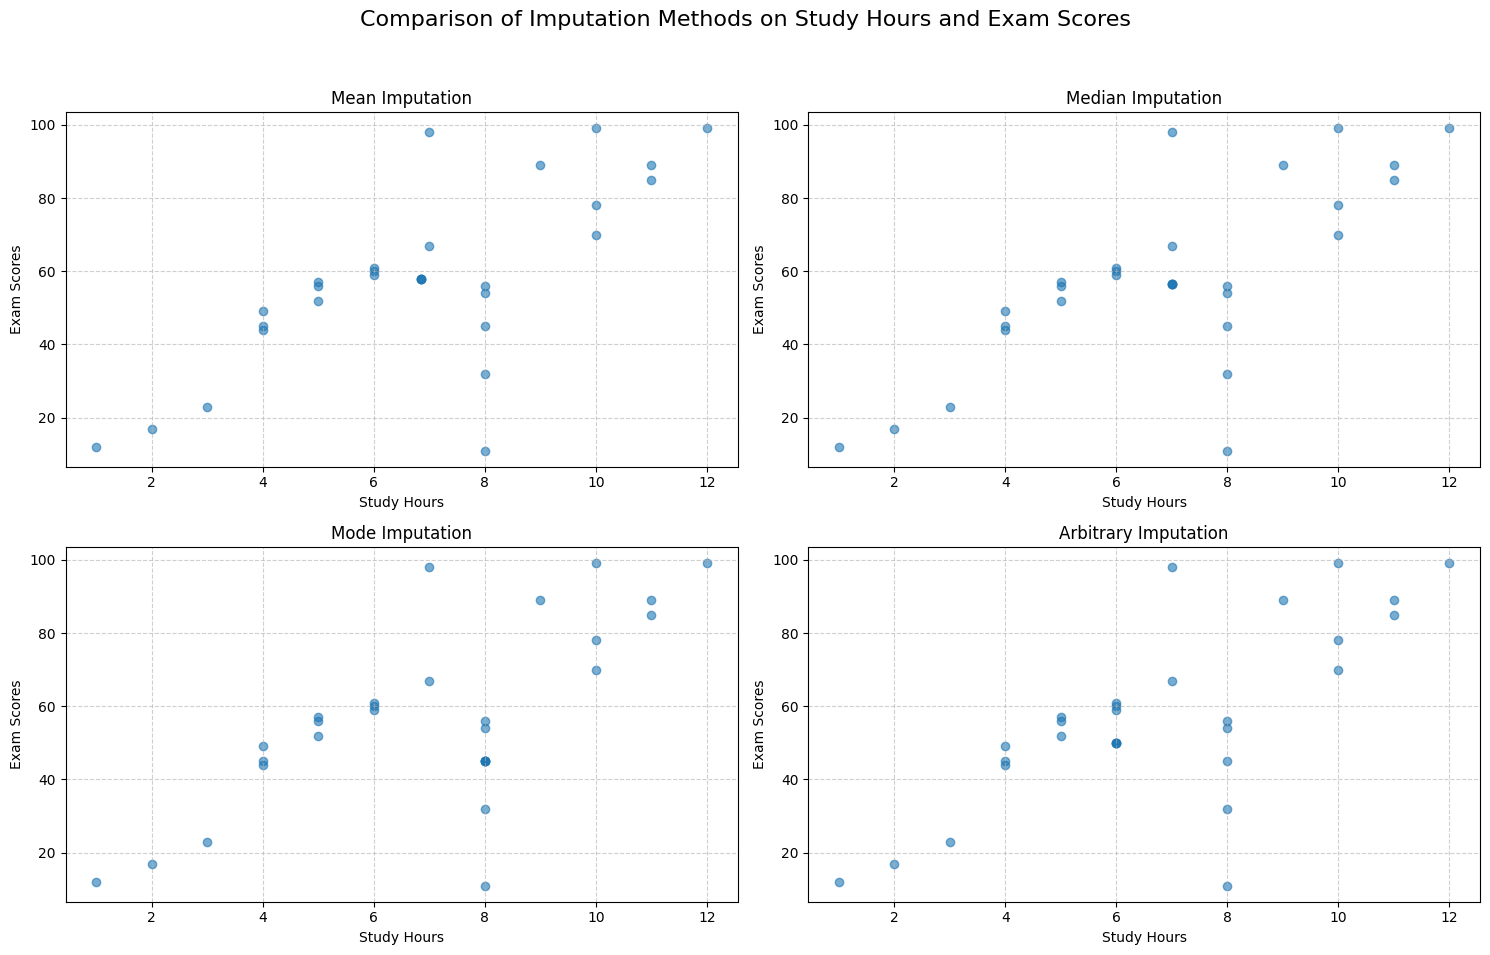

In [ ]:
import matplotlib.pyplot as plt

# List of dataframes and their labels
dfs = [mean_df, median_df, mode_df, arbitrary_df]
labels = ['Mean Imputation', 'Median Imputation', 'Mode Imputation', 'Arbitrary Imputation']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Comparison of Imputation Methods on Study Hours and Exam Scores', fontsize=16)

axes = axes.flatten()

for i, (temp_df, label) in enumerate(zip(dfs, labels)):
    axes[i].scatter(temp_df['Study Hours'], temp_df['Exam Scores'], alpha=0.6, label=label)
    axes[i].set_title(label)
    axes[i].set_xlabel('Study Hours')
    axes[i].set_ylabel('Exam Scores')
    axes[i].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

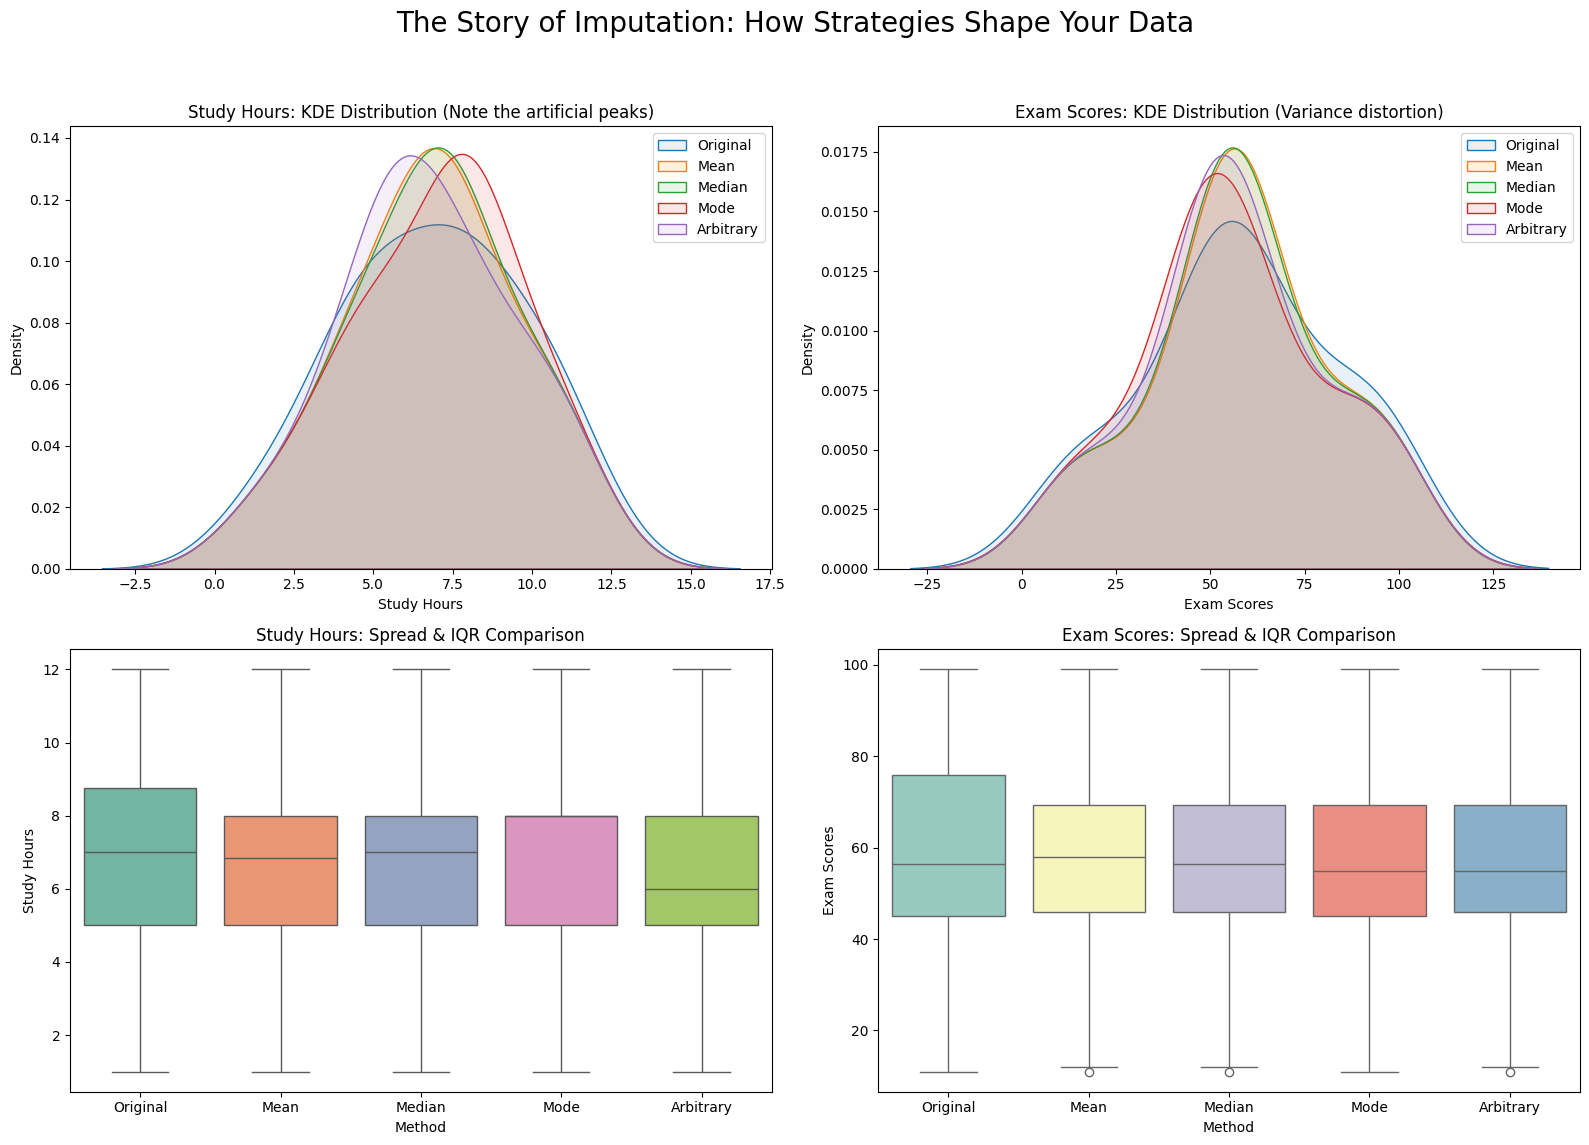

THE DECISION STORY:
- Mean/Median methods create a 'tall peak' at the center, reducing natural data noise.
- Mode imputation shifts the data toward specific clusters, potentially biasing categorical trends.
- Arbitrary imputation (e.g., filling with 6) creates a new outlier group that didn't exist.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Helper function to create a clean long-form dataframe for plotting
def prepare_plot_data(df_dict, column_name):
    data_list = []
    for label, df in df_dict.items():
        temp = df[column_name].dropna().to_frame()
        temp['Method'] = label
        data_list.append(temp)
    return pd.concat(data_list, ignore_index=True)

# Prepare data for plotting
dfs_to_compare = {
    'Original': data_df,
    'Mean': mean_df,
    'Median': median_df,
    'Mode': mode_df,
    'Arbitrary': arbitrary_df
}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('The Story of Imputation: How Strategies Shape Your Data', fontsize=20)

# 1. KDE Distribution: Study Hours
for label, temp_df in dfs_to_compare.items():
    sns.kdeplot(temp_df['Study Hours'].dropna(), ax=axes[0, 0], label=label, fill=True, alpha=0.1)
axes[0, 0].set_title('Study Hours: KDE Distribution (Note the artificial peaks)')
axes[0, 0].legend()

# 2. KDE Distribution: Exam Scores
for label, temp_df in dfs_to_compare.items():
    sns.kdeplot(temp_df['Exam Scores'].dropna(), ax=axes[0, 1], label=label, fill=True, alpha=0.1)
axes[0, 1].set_title('Exam Scores: KDE Distribution (Variance distortion)')
axes[0, 1].legend()

# 3. Boxplot: Study Hours
study_plot_data = prepare_plot_data(dfs_to_compare, 'Study Hours')
sns.boxplot(data=study_plot_data, x='Method', y='Study Hours', ax=axes[1, 0], palette='Set2', hue='Method', legend=False)
axes[1, 0].set_title('Study Hours: Spread & IQR Comparison')

# 4. Boxplot: Exam Scores
scores_plot_data = prepare_plot_data(dfs_to_compare, 'Exam Scores')
sns.boxplot(data=scores_plot_data, x='Method', y='Exam Scores', ax=axes[1, 1], palette='Set3', hue='Method', legend=False)
axes[1, 1].set_title('Exam Scores: Spread & IQR Comparison')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("THE DECISION STORY:")
print("- Mean/Median methods create a 'tall peak' at the center, reducing natural data noise.")
print("- Mode imputation shifts the data toward specific clusters, potentially biasing categorical trends.")
print("- Arbitrary imputation (e.g., filling with 6) creates a new outlier group that didn't exist.")

### Decision Matrix: Pros & Cons of Imputation Strategies

| Imputation Method | Pros | Cons | Best Use Case |
| :--- | :--- | :--- | :--- |
| **Mean** | Easy to implement; preserves the average of the dataset. | Distorts variance/covariance; creates artificial peaks in distribution. | Data is missing completely at random (MCAR) and distribution is normal. |
| **Median** | Robust to outliers; better for skewed distributions than mean. | Similar to mean, it reduces variance and alters the relationship between variables. | Skewed numerical data where you want to maintain central tendency. |
| **Mode** | Works for both numerical and categorical data. | Can significantly bias the data toward the most frequent value, masking diversity. | Categorical data with a clear dominant class. |
| **Arbitrary** | Highlights which values were originally missing; good for flagging. | Can introduce significant bias or create 'fake' patterns that mislead models. | When the fact that data is missing is itself an important feature. |
| **Regression** | Preserves relationships between features; more accurate than simple averages. | Complex to implement; can lead to over-fitting if the model is too simple. | When features are highly correlated (e.g., Study Hours and Exam Scores). |

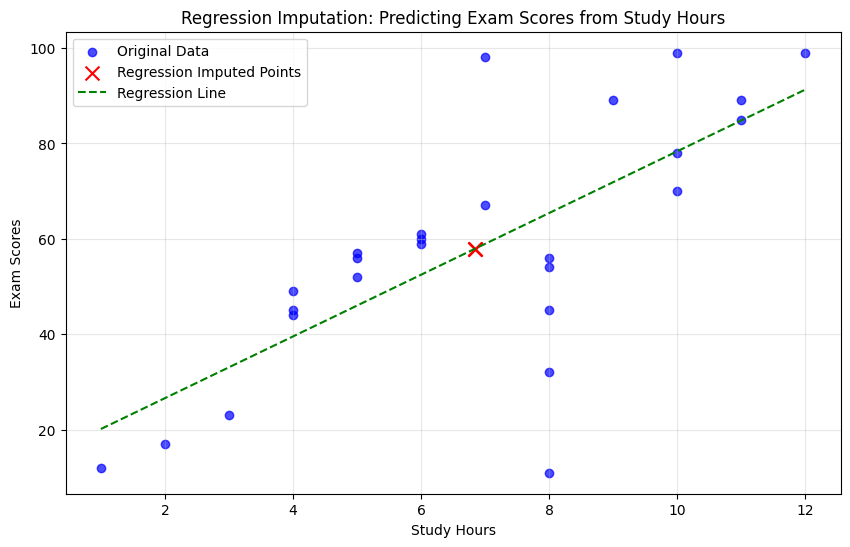

,Study Hours,Exam Scores
17,6.846154,57.961538
18,6.846154,57.961538
28,6.846154,57.961538
29,6.846154,57.961538


In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Prepare the Regression Imputed DataFrame
regression_df = data_df.copy()

# Identify training data (where both columns are non-null)
train_data = data_df.dropna(subset=['Study Hours', 'Exam Scores'])
X_train = train_data[['Study Hours']].values
y_train = train_data['Exam Scores'].values

# Train the model
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)

# Find rows where Study Hours is present but Exam Scores is NaN (if any)
# In this data_df, rows 17, 18, 28, 29 are missing both.
# Let's impute 'Exam Scores' based on 'Study Hours' for visualization.
# If Study Hours is also NaN, we'll fill Study Hours with the mean first to allow prediction.
regression_df['Study Hours'] = regression_df['Study Hours'].fillna(regression_df['Study Hours'].mean())

# Predict missing Exam Scores
predicted_scores = reg_model.predict(regression_df[['Study Hours']].values)
regression_df['Exam Scores'] = regression_df.apply(
    lambda row: reg_model.predict([[row['Study Hours']]])[0] if pd.isnull(row['Exam Scores']) else row['Exam Scores'],
    axis=1
)

# 2. Visualization
plt.figure(figsize=(10, 6))
plt.scatter(data_df['Study Hours'], data_df['Exam Scores'], color='blue', label='Original Data', alpha=0.7)

# Highlight Imputed Points
missing_indices = data_df[data_df['Exam Scores'].isna()].index
plt.scatter(regression_df.loc[missing_indices, 'Study Hours'],
            regression_df.loc[missing_indices, 'Exam Scores'],
            color='red', marker='x', s=100, label='Regression Imputed Points')

# Plot Regression Line
x_range = np.linspace(regression_df['Study Hours'].min(), regression_df['Study Hours'].max(), 100).reshape(-1, 1)
plt.plot(x_range, reg_model.predict(x_range), color='green', linestyle='--', label='Regression Line')

plt.title('Regression Imputation: Predicting Exam Scores from Study Hours')
plt.xlabel('Study Hours')
plt.ylabel('Exam Scores')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(regression_df.iloc[missing_indices])

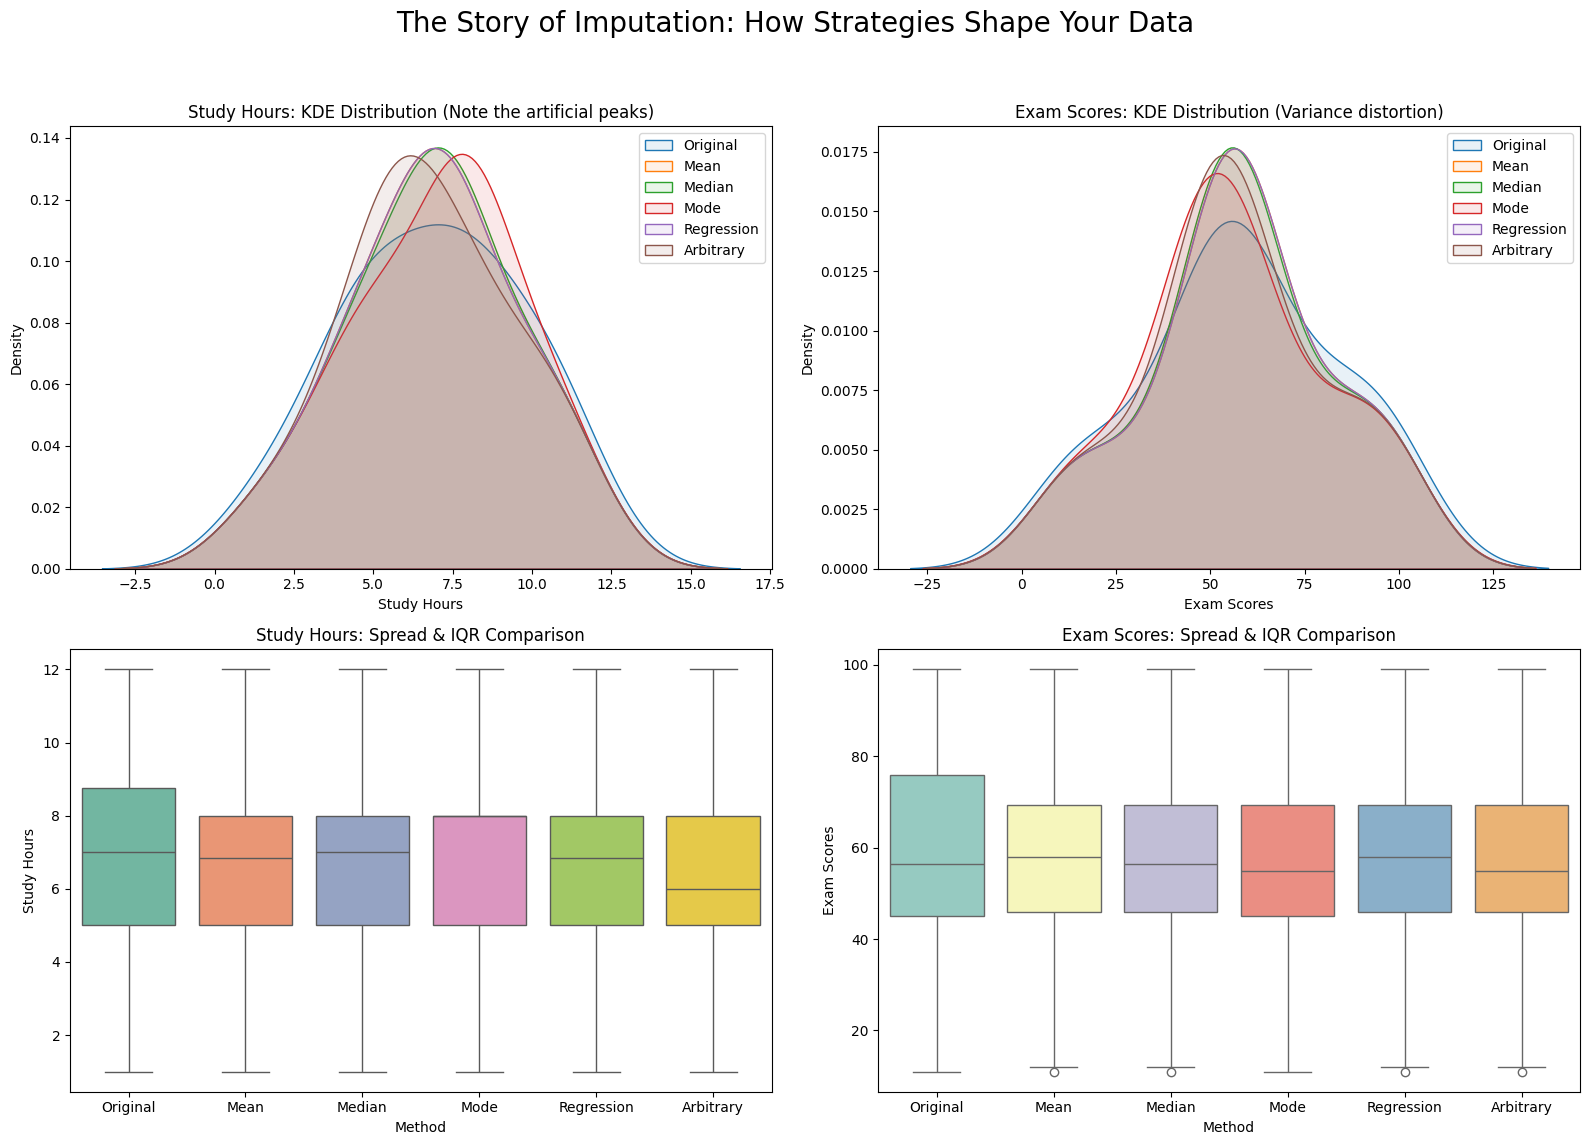

THE DECISION STORY:
- Mean/Median methods create a 'tall peak' at the center, reducing natural data noise.
- Mode imputation shifts the data toward specific clusters, potentially biasing categorical trends.
- Arbitrary imputation (e.g., filling with 6) creates a new outlier group that didn't exist.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Helper function to create a clean long-form dataframe for plotting
def prepare_plot_data(df_dict, column_name):
    data_list = []
    for label, df in df_dict.items():
        temp = df[column_name].dropna().to_frame()
        temp['Method'] = label
        data_list.append(temp)
    return pd.concat(data_list, ignore_index=True)

# Prepare data for plotting
dfs_to_compare = {
    'Original': data_df,
    'Mean': mean_df,
    'Median': median_df,
    'Mode': mode_df,
    'Regression': regression_df,    'Arbitrary': arbitrary_df

}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('The Story of Imputation: How Strategies Shape Your Data', fontsize=20)

# 1. KDE Distribution: Study Hours
for label, temp_df in dfs_to_compare.items():
    sns.kdeplot(temp_df['Study Hours'].dropna(), ax=axes[0, 0], label=label, fill=True, alpha=0.1)
axes[0, 0].set_title('Study Hours: KDE Distribution (Note the artificial peaks)')
axes[0, 0].legend()

# 2. KDE Distribution: Exam Scores
for label, temp_df in dfs_to_compare.items():
    sns.kdeplot(temp_df['Exam Scores'].dropna(), ax=axes[0, 1], label=label, fill=True, alpha=0.1)
axes[0, 1].set_title('Exam Scores: KDE Distribution (Variance distortion)')
axes[0, 1].legend()

# 3. Boxplot: Study Hours
study_plot_data = prepare_plot_data(dfs_to_compare, 'Study Hours')
sns.boxplot(data=study_plot_data, x='Method', y='Study Hours', ax=axes[1, 0], palette='Set2', hue='Method', legend=False)
axes[1, 0].set_title('Study Hours: Spread & IQR Comparison')

# 4. Boxplot: Exam Scores
scores_plot_data = prepare_plot_data(dfs_to_compare, 'Exam Scores')
sns.boxplot(data=scores_plot_data, x='Method', y='Exam Scores', ax=axes[1, 1], palette='Set3', hue='Method', legend=False)
axes[1, 1].set_title('Exam Scores: Spread & IQR Comparison')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("THE DECISION STORY:")
print("- Mean/Median methods create a 'tall peak' at the center, reducing natural data noise.")
print("- Mode imputation shifts the data toward specific clusters, potentially biasing categorical trends.")
print("- Arbitrary imputation (e.g., filling with 6) creates a new outlier group that didn't exist.")

In [ ]:
import pandas as pd

# Dictionary of all dataframes to compare
comparison_dict = {
    'Original (Dropped NA)': data_df.dropna(),
    'Mean Imputed': mean_df,
    'Median Imputed': median_df,
    'Mode Imputed': mode_df,
    'Arbitrary Imputed': arbitrary_df,
    'Regression Imputed': regression_df
}

# Calculate metrics for each
summary_list = []
for name, temp_df in comparison_dict.items():
    summary_list.append({
        'Method': name,
        'Study Hours Mean': temp_df['Study Hours'].mean(),
        'Exam Scores Mean': temp_df['Exam Scores'].mean(),
        'Exam Scores StdDev': temp_df['Exam Scores'].std(),
        'Correlation (Hrs vs Score)': temp_df['Study Hours'].corr(temp_df['Exam Scores'])
    })

summary_comparison = pd.DataFrame(summary_list)

print("--- Quantitative Comparison of Imputation Methods ---")
display(summary_comparison)

print("\nKEY INSIGHTS:")
print("1. Similarity: Most methods (except Arbitrary) keep the Mean close to the Original.")
print("2. Difference (Variance): Notice how Mean/Median/Mode reduce the StdDev (Exam Scores StdDev) compared to Original.")
print("3. The Regression Advantage: 'Regression Imputed' maintains a high Correlation, whereas Mean/Median/Mode/Arbitrary tend to dilute the strength of the relationship.")

--- Quantitative Comparison of Imputation Methods ---


,Method,Study Hours Mean,Exam Scores Mean,Exam Scores StdDev,Correlation (Hrs vs Score)
0,Original (Dropped NA),6.846154,57.961538,25.949922,0.724564
1,Mean Imputed,6.846154,57.961538,24.093898,0.724564
2,Median Imputed,6.866667,57.766667,24.099196,0.723851
3,Mode Imputed,7.000000,56.233333,24.507118,0.677966
4,Arbitrary Imputed,6.733333,56.900000,24.250631,0.727920
5,Regression Imputed,6.846154,57.961538,24.093898,0.724564



KEY INSIGHTS:
1. Similarity: Most methods (except Arbitrary) keep the Mean close to the Original.
2. Difference (Variance): Notice how Mean/Median/Mode reduce the StdDev (Exam Scores StdDev) compared to Original.
3. The Regression Advantage: 'Regression Imputed' maintains a high Correlation, whereas Mean/Median/Mode/Arbitrary tend to dilute the strength of the relationship.


In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression

# Reshape X and Y so each number is a separate sample (4 samples, 1 feature)
X = np.array([2, 7, 6, 8]).reshape(-1, 1)
print(X)
print(Y)
Y = np.array([16, 56, 48, 64]).reshape(-1, 1)

model = LinearRegression()
model.fit(X, Y)

# Predict for X = 3
prediction = model.predict([[3]])
print(f"Predicted Y for X=3: {prediction[0][0]}")

[[2]
 [7]
 [6]
 [8]]
[[16]
 [56]
 [48]
 [64]]
Predicted Y for X=3: 24.0
